In [1]:
from __future__ import print_function, unicode_literals, absolute_import, division
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from csbdeep.utils import axes_dict, plot_some, plot_history
from csbdeep.utils.tf import limit_gpu_memory
from csbdeep.io import load_training_data
from csbdeep.models import Config, CARE

2026-03-02 22:03:03.223531: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
(X,Y), (X_val,Y_val), axes = load_training_data('/storage/home/hcoda1/9/hxu419/scratch/training_merged_wpermuted_20260302_PACE.npz', validation_split=0.1, verbose=True)

c = axes_dict(axes)['C'] 
n_channel_in, n_channel_out = X.shape[c], Y.shape[c]

number of training images:	 76682
number of validation images:	 8520
image size (3D):		 (96, 32, 32)
axes:				 SZYXC
channels in / out:		 1 / 1


Text(0.5, 0.98, '5 example validation patches (top row: source, bottom row: target)')

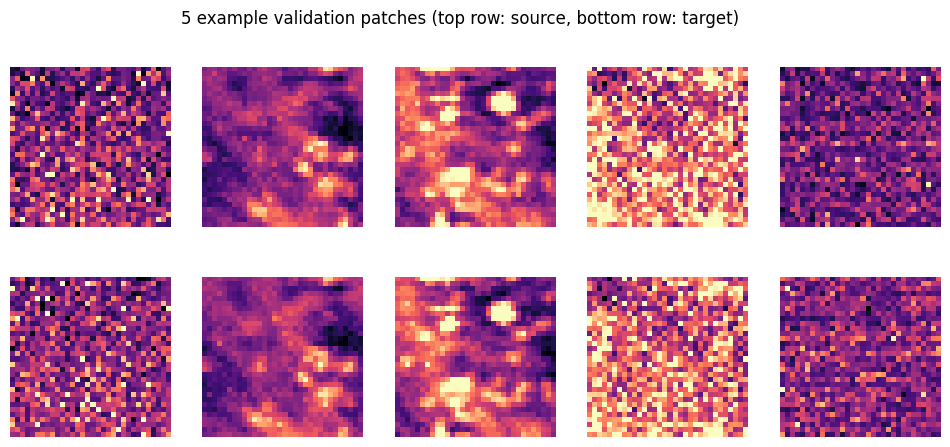

In [3]:
plt.figure(figsize=(12,5))
plot_some(X_val[:5],Y_val[:5])
plt.suptitle('5 example validation patches (top row: source, bottom row: target)')

In [4]:
config = Config(
    axes= axes,                # 3D with channel-last
    n_channel_in=1,
    n_channel_out=1,
    probabilistic=False,
    unet_residual=True,
    unet_n_depth=4,
    unet_kern_size=3,
    unet_n_first=32,
    train_epochs=100,
    train_steps_per_epoch=100,
)
print(config)
vars(config)

Config(n_dim=3, axes='ZYXC', n_channel_in=1, n_channel_out=1, train_checkpoint='weights_best.h5', train_checkpoint_last='weights_last.h5', train_checkpoint_epoch='weights_now.h5', probabilistic=False, unet_residual=True, unet_n_depth=4, unet_kern_size=3, unet_n_first=32, unet_last_activation='linear', unet_input_shape=(None, None, None, 1), train_loss='mae', train_epochs=100, train_steps_per_epoch=100, train_learning_rate=0.0004, train_batch_size=16, train_tensorboard=True, train_reduce_lr={'factor': 0.5, 'patience': 10, 'min_delta': 0})


{'n_dim': 3,
 'axes': 'ZYXC',
 'n_channel_in': 1,
 'n_channel_out': 1,
 'train_checkpoint': 'weights_best.h5',
 'train_checkpoint_last': 'weights_last.h5',
 'train_checkpoint_epoch': 'weights_now.h5',
 'probabilistic': False,
 'unet_residual': True,
 'unet_n_depth': 4,
 'unet_kern_size': 3,
 'unet_n_first': 32,
 'unet_last_activation': 'linear',
 'unet_input_shape': (None, None, None, 1),
 'train_loss': 'mae',
 'train_epochs': 100,
 'train_steps_per_epoch': 100,
 'train_learning_rate': 0.0004,
 'train_batch_size': 16,
 'train_tensorboard': True,
 'train_reduce_lr': {'factor': 0.5, 'patience': 10, 'min_delta': 0}}

In [5]:
model = CARE(config, 'wpermute_model_4layers_20260302', basedir='/storage/home/hcoda1/9/hxu419/scratch/models')

I0000 00:00:1772507301.369489 2464107 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79191 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:25:00.0, compute capability: 8.0


In [6]:
history = model.train(X,Y, validation_data=(X_val,Y_val))

Epoch 1/100


2026-03-02 22:08:26.583319: I external/local_xla/xla/service/service.cc:163] XLA service 0x1543b80036c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-02 22:08:26.583345: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2026-03-02 22:08:26.739976: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-02 22:08:27.417606: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
I0000 00:00:1772507324.258405 2466375 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0939 - mae: 0.0939 - mse: 0.0193

/storage/home/hcoda1/9/hxu419/.conda/envs/BCARS_N2N/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input
Received: inputs=('Tensor(shape=(1, 96, 32, 32, 1))',)
  warnings.warn(msg)


100/100 ━━━━━━━━━━━━━━━━━━━━ 51s 300ms/step - loss: 0.0861 - mae: 0.0861 - mse: 0.0164 - val_loss: 0.0753 - val_mae: 0.0753 - val_mse: 0.0125 - learning_rate: 4.0000e-04
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 151ms/step - loss: 0.0764 - mae: 0.0764 - mse: 0.0128 - val_loss: 0.0739 - val_mae: 0.0739 - val_mse: 0.0120 - learning_rate: 4.0000e-04
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - loss: 0.0735 - mae: 0.0735 - mse: 0.0119 - val_loss: 0.0733 - val_mae: 0.0733 - val_mse: 0.0118 - learning_rate: 4.0000e-04
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 153ms/step - loss: 0.0732 - mae: 0.0732 - mse: 0.0117 - val_loss: 0.0732 - val_mae: 0.0732 - val_mse: 0.0117 - learning_rate: 4.0000e-04
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 155ms/step - loss: 0.0733 - mae: 0.0733 - mse: 0.0118 - val_loss: 0.0728 - val_mae: 0.0728 - val_mse: 0.0116 - learning_rate: 4.0000e-04
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 153ms/step - loss: 0.0715 - mae: 0.0715 - mse: 0.0112 - v

['learning_rate', 'loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse']


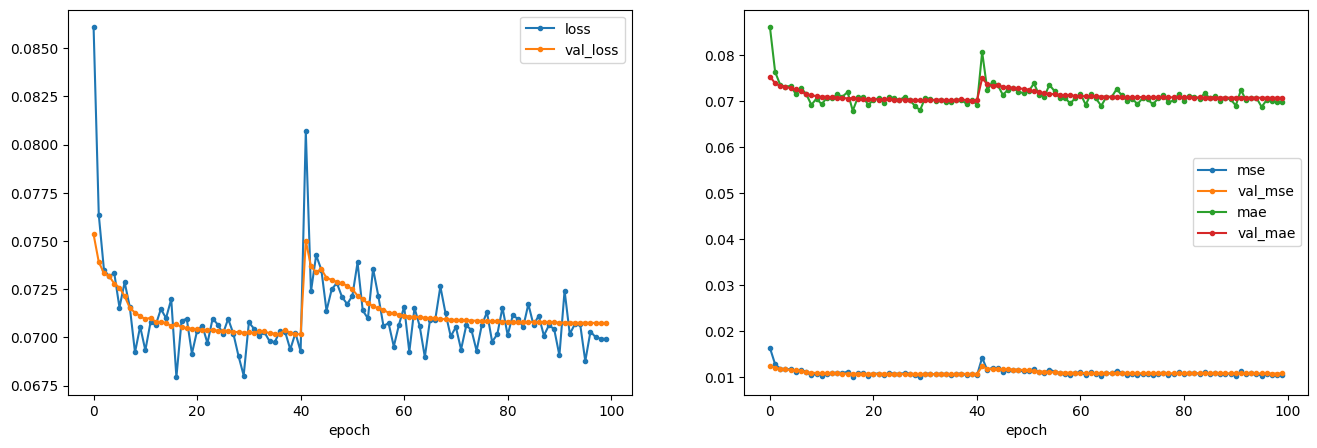

In [7]:
print(sorted(list(history.history.keys())))
plt.figure(figsize=(16,5))
plot_history(history,['loss','val_loss'],['mse','val_mse','mae','val_mae']);

In [8]:
import tensorflow as tf
opt = model.keras_model.optimizer

# # Works in TF2.x
# try:
#     opt.learning_rate.assign(2e-4)
# except AttributeError:
#     # Older TF/Keras uses .lr
#     tf.keras.backend.set_value(opt.lr, 2e-4)

history2 = model.train(X, Y, validation_data=(X_val, Y_val),
                       epochs=100, steps_per_epoch=100)

Epoch 1/100


100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 226ms/step - loss: 0.0696 - mae: 0.0696 - mse: 0.0105 - val_loss: 0.0701 - val_mae: 0.0701 - val_mse: 0.0107 - learning_rate: 6.2500e-06
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - loss: 0.0696 - mae: 0.0696 - mse: 0.0105 - val_loss: 0.0701 - val_mae: 0.0701 - val_mse: 0.0107 - learning_rate: 6.2500e-06
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 155ms/step - loss: 0.0698 - mae: 0.0698 - mse: 0.0105 - val_loss: 0.0701 - val_mae: 0.0701 - val_mse: 0.0106 - learning_rate: 6.2500e-06
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - loss: 0.0697 - mae: 0.0697 - mse: 0.0106 - val_loss: 0.0701 - val_mae: 0.0701 - val_mse: 0.0106 - learning_rate: 6.2500e-06
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 156ms/step - loss: 0.0694 - mae: 0.0694 - mse: 0.0105 - val_loss: 0.0701 - val_mae: 0.0701 - val_mse: 0.0106 - learning_rate: 6.2500e-06
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - loss: 0.0685 - mae: 0.0685 - mse: 0.0102 - v

['learning_rate', 'loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse']


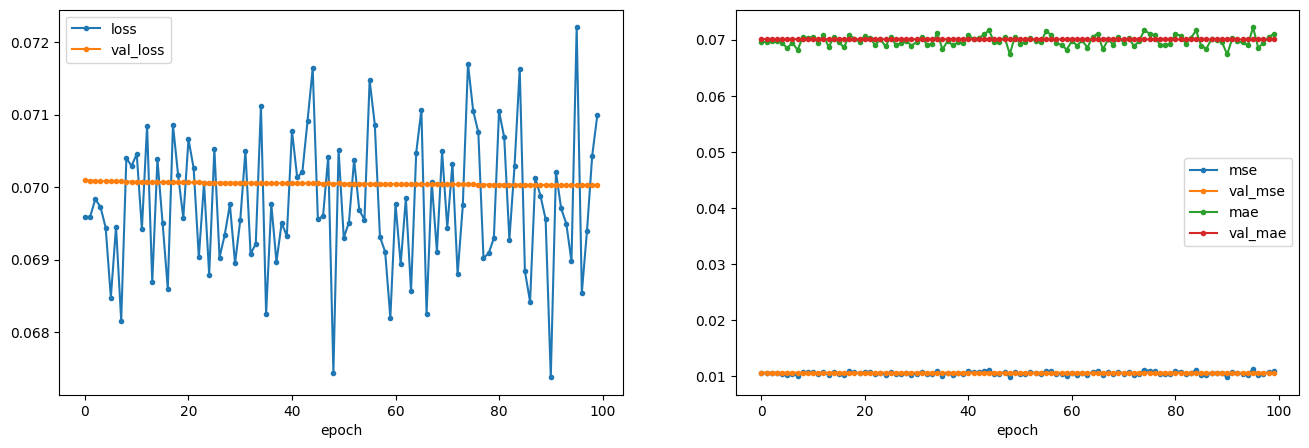

In [9]:
print(sorted(list(history2.history.keys())))
plt.figure(figsize=(16,5))
plot_history(history2,['loss','val_loss'],['mse','val_mse','mae','val_mae']);

In [10]:
history3 = model.train(X, Y, validation_data=(X_val, Y_val),
                       epochs=100, steps_per_epoch=100)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 207ms/step - loss: 0.0317 - mae: 0.0317 - mse: 0.0021 - val_loss: 0.0318 - val_mae: 0.0318 - val_mse: 0.0021 - learning_rate: 2.5000e-05
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - loss: 0.0319 - mae: 0.0319 - mse: 0.0021 - val_loss: 0.0318 - val_mae: 0.0318 - val_mse: 0.0021 - learning_rate: 2.5000e-05
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - loss: 0.0314 - mae: 0.0314 - mse: 0.0020 - val_loss: 0.0318 - val_mae: 0.0318 - val_mse: 0.0021 - learning_rate: 2.5000e-05
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - loss: 0.0317 - mae: 0.0317 - mse: 0.0021 - val_loss: 0.0318 - val_mae: 0.0318 - val_mse: 0.0021 - learning_rate: 2.5000e-05
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - loss: 0.0318 - mae: 0.0318 - mse: 0.0021 - val_loss: 0.0318 - val_mae: 0.0318 - val_mse: 0.0021 - learning_rate: 2.5000e-05
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - loss: 0.0315 - mae: 0.0315 - mse

['learning_rate', 'loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse']


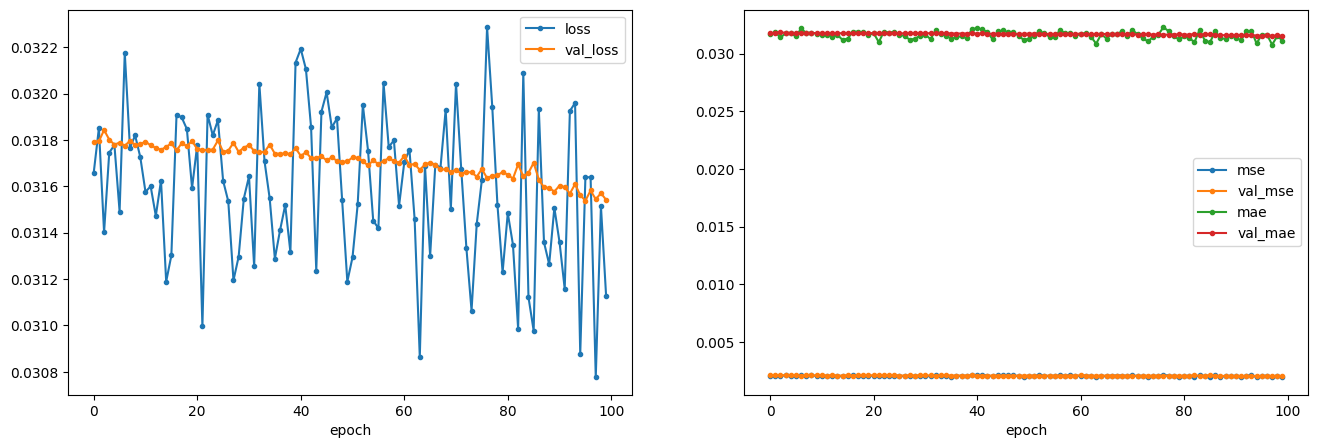

In [11]:
print(sorted(list(history3.history.keys())))
plt.figure(figsize=(16,5))
plot_history(history3,['loss','val_loss'],['mse','val_mse','mae','val_mae']);

In [16]:
import tensorflow as tf
opt = model.keras_model.optimizer

# Works in TF2.x
try:
    opt.learning_rate.assign(1e-4)
except AttributeError:
    # Older TF/Keras uses .lr
    tf.keras.backend.set_value(opt.lr, 1e-4)
history4 = model.train(X, Y, validation_data=(X_val, Y_val),
                       epochs=100, steps_per_epoch=100)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0403 - mae: 0.0403 - mse: 0.0030 - val_loss: 0.0414 - val_mae: 0.0414 - val_mse: 0.0033 - learning_rate: 1.0000e-04
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0402 - mae: 0.0402 - mse: 0.0030 - val_loss: 0.0413 - val_mae: 0.0413 - val_mse: 0.0032 - learning_rate: 1.0000e-04
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0403 - mae: 0.0403 - mse: 0.0030 - val_loss: 0.0414 - val_mae: 0.0414 - val_mse: 0.0033 - learning_rate: 1.0000e-04
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0403 - mae: 0.0403 - mse: 0.0030 - val_loss: 0.0413 - val_mae: 0.0413 - val_mse: 0.0032 - learning_rate: 1.0000e-04
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0402 - mae: 0.0402 - mse: 0.0030 - val_loss: 0.0412 - val_mae: 0.0412 - val_mse: 0.0032 - learning_rate: 1.0000e-04
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0401 - mae: 0.0401 - mse: 0.0029 - v

['learning_rate', 'loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse']


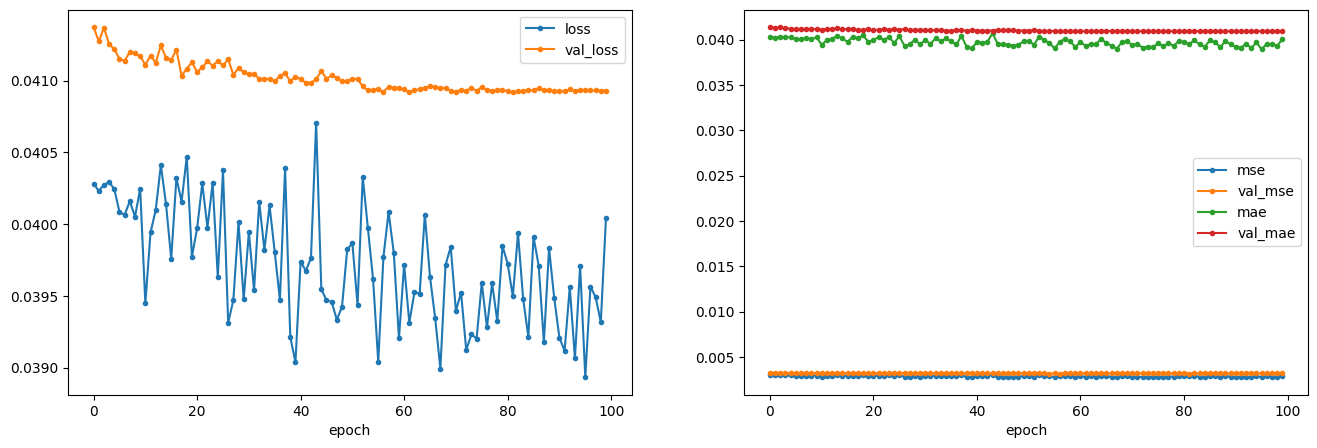

In [18]:
print(sorted(list(history4.history.keys())))
plt.figure(figsize=(16,5))
plot_history(history4,['loss','val_loss'],['mse','val_mse','mae','val_mae']);

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


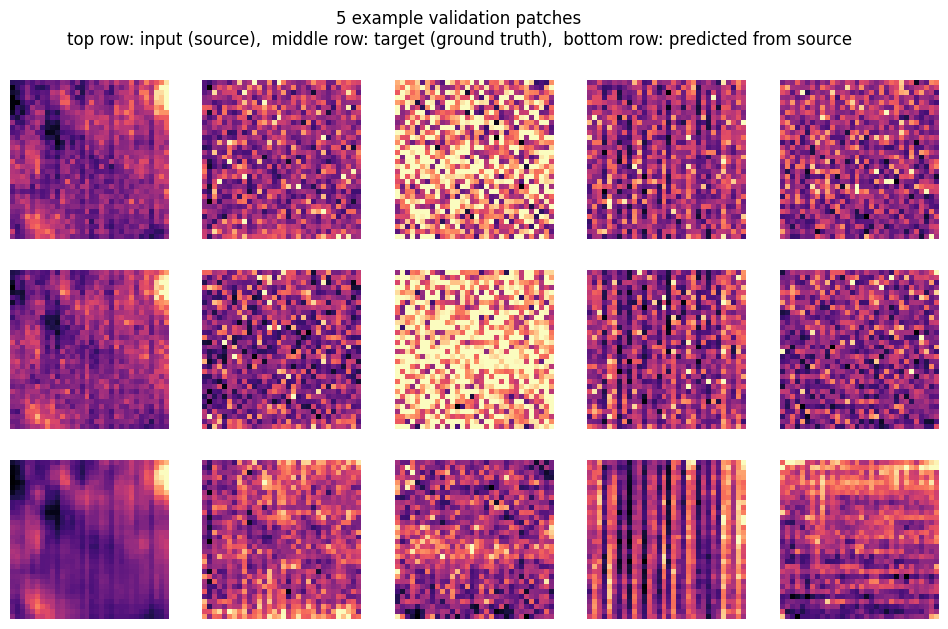

In [10]:
plt.figure(figsize=(12,7))
_P = model.keras_model.predict(X_val[5:10])
if config.probabilistic:
    _P = _P[...,:(_P.shape[-1]//2)]
plot_some(X_val[5:10],Y_val[5:10],_P,pmax=99.5)
plt.suptitle('5 example validation patches\n'      
             'top row: input (source),  '          
             'middle row: target (ground truth),  '
             'bottom row: predicted from source');

In [13]:
print(_P.shape)

(5, 96, 32, 32, 1)
